In [1]:
import tensorflow as tf
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError, BinaryCrossentropy, SparseCategoricalCrossentropy
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

In [58]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler 
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, train_test_split, GridSearchCV
 
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import sklearn.cluster as sk_cluster
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, confusion_matrix, accuracy_score, classification_report
import scipy.stats as stats
from scipy.stats import chi2_contingency
from scipy.cluster.hierarchy import linkage, dendrogram

In [7]:
import networkx as nx
import heapq

In [9]:
# Adjust the path to match your Box sync folder location
box_path = os.path.expanduser(r"C:\Users\HIALAB\Box\Human_AGV_project\ISU_Modeling\Code")

In [11]:
# Specify the directory and filename
save_dir = "./Images/"

In [13]:
study_data_by_sec = pd.read_csv(os.path.join(box_path, 'study_data_by_sec_processed.csv'))
study_data_by_sec

,User_X,User_Y,User_Z,User_Pitch,User_Yaw,User_Roll,U_X,U_Y,U_Z,GazeOrigin_X,...,PID,DRate,User_Relative_Speed,AGV_Relative_Speed,AGV_User_distance,EyeTarget,Angle_to_AGV,AGV_in_FOV,Angle_to_Destination,Destination_in_FOV
0,5051.235,8610.830,-209.725,-21.168361,-92.384752,0.290698,60.493000,-108.133857,156.034571,4990.742143,...,1,High,0.0,84.241150,6811.521389,BP_Affordance_C_0,203.080077,False,112.737321,False
1,5051.235,8610.830,-209.725,-21.168361,-92.384752,0.290698,60.493000,-108.133857,156.034571,4990.742143,...,1,High,0.0,84.241150,6811.521389,BP_Affordance_C_0,203.080077,False,112.737321,False
2,5051.235,8610.830,-209.725,-21.168361,-92.384752,0.290698,60.493000,-108.133857,156.034571,4990.742143,...,1,High,0.0,84.241150,6811.521389,BP_Affordance_C_0,203.080077,False,112.737321,False
3,5051.235,8610.830,-209.725,-21.168361,-92.384752,0.290698,60.493000,-108.133857,156.034571,4990.742143,...,1,High,0.0,84.241150,6811.521389,BP_Affordance_C_0,203.080077,False,112.737321,False
4,5051.235,8610.830,-209.725,-21.168361,-92.384752,0.290698,60.493000,-108.133857,156.034571,4990.742143,...,1,High,0.0,84.241150,6811.521389,BP_Affordance_C_0,203.080077,False,112.737321,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7376308,4814.045,8544.847,-209.725,7.603790,-93.517554,0.112428,-57.683000,-37.738571,162.621143,4871.727857,...,46,Low,0.0,0.313207,3573.126479,BP_CheckPoint3,324.469750,False,90.000000,True
7376309,4814.045,8544.847,-209.725,9.593631,-101.241813,-2.028508,-59.239429,-37.026714,162.851143,4873.284286,...,46,Low,0.0,0.299045,3572.918260,BP_CheckPoint3,324.691134,False,90.000000,True
7376310,4814.045,8544.847,-209.725,10.106079,-86.682990,-1.234411,-57.745714,-36.808571,162.943429,4871.790429,...,46,Low,0.0,0.309687,3572.707442,BP_CheckPoint3,353.788991,False,90.000000,True
7376311,4814.045,8544.847,-209.725,10.802710,-103.167978,-1.137901,-59.808714,-36.247000,163.049286,4873.853429,...,46,Low,0.0,0.313157,3572.496169,BP_CheckPoint3,335.098915,False,90.000000,True


In [14]:
data = pd.read_csv(os.path.join(box_path, 'Per_Interaction_Data_Merged.csv'))
data

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,AGV_Path_Complexity,Trust_before,Cross_First_Flag,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_3,Frechet_Distance_5,Frechet_Distance_7,Frechet_Distance_10,Cross_First
0,1,High,2024-5-3,14,28,53,1,1900-01-01 15:02:48,1900-01-01 15:03:38,219,...,Straight,4.9,True,74.580213,100.420508,730.13,1188.92,1532.83,1771.61,N\A
1,1,High,2024-5-3,14,28,53,2,1900-01-01 15:03:47,1900-01-01 15:04:29,0,...,Complex,10.0,True,47.888087,232.345812,14.56,97.05,108.21,247.34,N\A
2,1,High,2024-5-3,14,28,53,3,1900-01-01 15:04:37,1900-01-01 15:05:34,268,...,Complex,10.0,True,63.130599,120.176130,282.09,482.54,821.32,1067.08,User
3,1,High,2024-5-3,14,28,53,4,1900-01-01 15:05:46,1900-01-01 15:06:37,779,...,Complex,10.0,True,43.571998,263.284416,421.34,544.15,577.55,610.84,User
4,1,High,2024-5-3,14,28,53,5,1900-01-01 15:06:41,1900-01-01 15:07:44,868,...,Complex,7.0,True,93.720008,91.614207,486.65,852.85,1225.51,1722.14,N\A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1317,46,Low,2024-8-26,16,55,4,12,1900-01-01 17:07:02,1900-01-01 17:08:21,595,...,Complex,9.0,NaN,77.121444,90.961763,224.51,507.80,789.37,1176.65,User
1318,46,Low,2024-8-26,16,55,4,13,1900-01-01 17:08:24,1900-01-01 17:09:05,0,...,Complex,9.0,NaN,54.297007,286.165319,420.27,627.75,714.38,937.14,AGV
1319,46,Low,2024-8-26,16,55,4,14,1900-01-01 17:09:08,1900-01-01 17:09:52,0,...,Straight,10.0,NaN,82.319060,221.787091,408.09,668.13,919.97,1180.07,User
1320,46,Low,2024-8-26,16,55,4,15,1900-01-01 17:09:56,1900-01-01 17:10:31,67,...,Straight,10.0,NaN,65.826092,278.817960,301.57,562.78,774.23,998.19,User


In [15]:
# Get the total number of null values in each column
null_counts = data.isnull().sum()
null_counts

PID                        0
DRate                      0
date                       0
hr                         0
min                        0
s                          0
AGVname                    0
StartTime                  0
EndTime                    0
GazeDuration               0
mean_dist                  0
min_dist                   0
max_dist                   0
std_dist                   0
mean_agv_spd               0
min_agv_spd                0
max_agv_spd                0
std_spd                    0
task                       0
Trust                      0
Safe                       0
Comfort                    0
Expect                     0
Age                        0
Gender                     0
Ethnicity                  0
GamingFrequency            0
VRExperience               0
VRHeadsetExperience        0
AGVInteraction             0
PerfectAutomation          0
TrustPropensity            0
AutomationExperience       0
Trust1                     0
Trust2        

In [16]:
data.columns

Index(['PID', 'DRate', 'date', 'hr', 'min', 's', 'AGVname', 'StartTime',
       'EndTime', 'GazeDuration', 'mean_dist', 'min_dist', 'max_dist',
       'std_dist', 'mean_agv_spd', 'min_agv_spd', 'max_agv_spd', 'std_spd',
       'task', 'Trust', 'Safe', 'Comfort', 'Expect', 'Age', 'Gender',
       'Ethnicity', 'GamingFrequency', 'VRExperience', 'VRHeadsetExperience',
       'AGVInteraction', 'PerfectAutomation', 'TrustPropensity',
       'AutomationExperience', 'Trust1', 'Trust2', 'MWL', 'Assessment',
       'Gaze_on_AGV', 'User_Trajectory', 'AGV_Approaching',
       'AGV_User_Combination', 'AGV_Path_Complexity', 'Trust_before',
       'Cross_First_Flag', 'User_Relative_Speed', 'AGV_Relative_Speed',
       'Frechet_Distance_3', 'Frechet_Distance_5', 'Frechet_Distance_7',
       'Frechet_Distance_10', 'Cross_First'],
      dtype='object')

In [17]:
study_data_by_sec['Timestamp'] = pd.to_datetime(study_data_by_sec['Timestamp'])

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_14764\1185219751.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  study_data_by_sec['Timestamp'] = pd.to_datetime(study_data_by_sec['Timestamp'])


In [18]:
study_data_by_sec.columns

Index(['User_X', 'User_Y', 'User_Z', 'User_Pitch', 'User_Yaw', 'User_Roll',
       'U_X', 'U_Y', 'U_Z', 'GazeOrigin_X', 'GazeOrigin_Y', 'GazeOrigin_Z',
       'GazeDirection_X', 'GazeDirection_Y', 'GazeDirection_Z', 'Confidence',
       'Gaze_on_AGV', 'AGV_X', 'AGV_Y', 'AGV_Z', 'AGV_Pitch', 'AGV_Yaw',
       'AGV_Roll', 'AGV_spd', 'Timestamp', 'AGVname', 'PID', 'DRate',
       'User_Relative_Speed', 'AGV_Relative_Speed', 'AGV_User_distance',
       'EyeTarget', 'Angle_to_AGV', 'AGV_in_FOV', 'Angle_to_Destination',
       'Destination_in_FOV'],
      dtype='object')

In [19]:
# Ensure consistent types
study_data_by_sec['PID'] = study_data_by_sec['PID'].astype(int)
study_data_by_sec['DRate'] = study_data_by_sec['DRate'].astype(str)
study_data_by_sec['AGVname'] = study_data_by_sec['AGVname'].astype(int)

data['PID'] = data['PID'].astype(int)
data['DRate'] = data['DRate'].astype(str)
data['AGVname'] = data['AGVname'].astype(int)

In [20]:
# Filter rows where Cross_First is None
missing_cross_first = data[data['Cross_First'].isna()]

# Display unique groups (PID, DRate, AGVname) where Cross_First is None
missing_groups = missing_cross_first[['PID', 'DRate', 'AGVname']].drop_duplicates()
missing_groups

,PID,DRate,AGVname
477,17,High,3
490,17,High,16
492,17,Low,2
493,17,Low,3
506,17,Low,16
...,...,...,...
1289,45,Low,16
1292,46,High,3
1305,46,High,16
1308,46,Low,3


In [21]:
# Remove rows from study_data_by_sec that match groups in missing_groups
study_data_by_sec = study_data_by_sec.merge(missing_groups, on=['PID', 'DRate', 'AGVname'], how='left', indicator=True)

# Keep only rows that **do not** appear in missing_groups
study_data_by_sec = study_data_by_sec[study_data_by_sec['_merge'] == 'left_only'].drop(columns=['_merge'])

In [22]:
filtered_data = []
potential_changing_decision = []  # Groups where Cross_First is "AGV"
potential_steady_decision = []  # Groups where Cross_First is "User"

k = 0  # Counter for processed groups
removed_groups = 0  # Counter for removed groups

# Process each group separately
for (pid, drate, agvname), group in study_data_by_sec.groupby(['PID', 'DRate', 'AGVname']):
    k += 1

    if group.empty:
        # print(f"Skipping empty group ({pid}, {drate}, {agvname})")
        continue

    # Find the row index with the minimum AGV_User_distance
    min_idx = group['AGV_User_distance'].idxmin()

    if pd.isna(min_idx):
        # print(f"min_idx is NaN for group ({pid}, {drate}, {agvname}) - Skipping")
        continue

    # print(f"Processing group ({pid}, {drate}, {agvname}): Min idx = {min_idx}")

    # Extract the corresponding Cross_First value from data **before using it**
    cross_first_value = data.loc[
        (data['PID'] == pid) & (data['DRate'] == drate) & (data['AGVname'] == agvname), 'Cross_First'
    ]

    if cross_first_value.empty:
        removed_groups += 1
        # print(f"Removing group ({pid}, {drate}, {agvname}) because Cross_First is NaN.")
        continue

    cross_first_value = cross_first_value.values[0]  # Extract the single value

    if cross_first_value not in ["User", "AGV"]:
        removed_groups += 1
        # print(f"Removing group ({pid}, {drate}, {agvname}) because Cross_First is invalid: {cross_first_value}")
        continue

    # Now, we safely assign it
    # print(f"Before Assignment: {study_data_by_sec.loc[min_idx, 'Cross_First']}")
    study_data_by_sec.at[min_idx, 'Cross_First'] = cross_first_value
    # print(f"After Assignment: {study_data_by_sec.loc[min_idx, 'Cross_First']}")

    # Keep only rows **up to** the min_idx row
    group_filtered = group.loc[:min_idx]

    if group_filtered.empty:
        # print(f"Group filtered empty after trimming - Skipping")
        continue

    filtered_data.append(group_filtered)

    if cross_first_value == "AGV":
        potential_changing_decision.append((pid, drate, agvname))
    elif cross_first_value == "User":
        potential_steady_decision.append((pid, drate, agvname))

print(f"Total groups processed: {k}")
print(f"Total groups removed: {removed_groups}")

# If filtered data exists, update study_data_by_sec
if filtered_data:
    study_data_by_sec = pd.concat(filtered_data, ignore_index=True)
else:
    study_data_by_sec = pd.DataFrame(columns=study_data_by_sec.columns)

# print(f"\nPotential Changing Decision (AGV): {len(potential_changing_decision)} groups")
# print(potential_changing_decision)

# print(f"\nPotential Steady Decision (User): {len(potential_steady_decision)} groups")
# print(potential_steady_decision)

Total groups processed: 1227
Total groups removed: 158


In [23]:
study_data_by_sec.iloc[0:20]

,User_X,User_Y,User_Z,User_Pitch,User_Yaw,User_Roll,U_X,U_Y,U_Z,GazeOrigin_X,...,PID,DRate,User_Relative_Speed,AGV_Relative_Speed,AGV_User_distance,EyeTarget,Angle_to_AGV,AGV_in_FOV,Angle_to_Destination,Destination_in_FOV
0,2200.416000,8600.156000,-209.963,-11.479123,-118.365545,3.151699,45.116500,-89.558000,160.919000,2155.299333,...,1,High,0.000000,0.00000,1275.129829,BP_Affordance_C_2,213.839254,False,3.40429,True
1,2200.416000,8600.156000,-209.963,-11.479123,-118.365545,3.151699,45.116500,-89.558000,160.919000,2155.299333,...,1,High,0.000000,0.00000,1275.129829,BP_Affordance_C_2,213.839254,False,3.40429,True
2,2200.416000,8600.156000,-209.963,-11.479123,-118.365545,3.151699,45.116500,-89.558000,160.919000,2155.299333,...,1,High,0.000000,0.00000,1275.129829,BP_Affordance_C_2,213.839254,False,3.40429,True
3,2200.416000,8600.156000,-209.963,-11.479123,-118.365545,3.151699,45.116500,-89.558000,160.919000,2155.299333,...,1,High,0.000000,0.00000,1275.129829,BP_Affordance_C_2,213.839254,False,3.40429,True
4,2200.416000,8600.156000,-209.963,-11.479123,-118.365545,3.151699,45.116500,-89.558000,160.919000,2155.299333,...,1,High,0.000000,0.00000,1275.129829,BP_Affordance_C_2,213.839254,False,3.40429,True
5,2200.416000,8600.156000,-209.963,-11.479123,-118.365545,3.151699,45.116500,-89.558000,160.919000,2155.299333,...,1,High,0.000000,0.00000,1275.129829,BP_Affordance_C_2,213.839254,False,3.40429,True
6,2200.416000,8600.156000,-209.963,-11.479123,-118.365545,3.151699,45.116500,-89.558000,160.919000,2155.299333,...,1,High,0.000000,0.00000,1275.129829,BP_Affordance_C_2,213.839254,False,3.40429,True
7,2200.416000,8600.156000,-209.963,-11.479123,-118.365545,3.151699,45.116500,-89.558000,160.919000,2155.299333,...,1,High,0.000000,0.00000,1275.129829,BP_Affordance_C_2,213.839254,False,3.40429,True
8,2200.416000,8600.156000,-209.963,-11.479123,-118.365545,3.151699,45.116500,-89.558000,160.919000,2155.299333,...,1,High,0.000000,0.00000,1275.129829,BP_Affordance_C_2,213.839254,False,3.40429,True
9,2200.416000,8600.156000,-209.963,-11.479123,-118.365545,3.151699,45.116500,-89.558000,160.919000,2155.299333,...,1,High,0.000000,0.00000,1275.129829,BP_Affordance_C_2,213.839254,False,3.40429,True


In [24]:
# Initialize column
study_data_by_sec['Cross_First'] = None  

# Step 1: Assign "User" to the first entry of each group
grouped = study_data_by_sec.groupby(['PID', 'DRate', 'AGVname'])
for _, group in grouped:
    first_idx = group.index.min()
    study_data_by_sec.at[first_idx, 'Cross_First'] = "User"

# Step 2: Assign "AGV" to the row with the minimum AGV_User_distance in potential_changing_decision
for pid, drate, agvname in potential_changing_decision:
    group = study_data_by_sec.loc[
        (study_data_by_sec['PID'] == pid) &
        (study_data_by_sec['DRate'] == drate) &
        (study_data_by_sec['AGVname'] == agvname)
    ]
    if not group.empty:
        min_idx = group['AGV_User_distance'].idxmin()
        study_data_by_sec.at[min_idx, 'Cross_First'] = "AGV"

# Step 3: Assign "User" to the row with the minimum AGV_User_distance in potential_steady_decision
for pid, drate, agvname in potential_steady_decision:
    group = study_data_by_sec.loc[
        (study_data_by_sec['PID'] == pid) &
        (study_data_by_sec['DRate'] == drate) &
        (study_data_by_sec['AGVname'] == agvname)
    ]
    if not group.empty:
        min_idx = group['AGV_User_distance'].idxmin()
        study_data_by_sec.at[min_idx, 'Cross_First'] = "User"

# Final status
print("\nFinal Cross_First Column Status:")
print(study_data_by_sec['Cross_First'].value_counts(dropna=False))


Final Cross_First Column Status:
Cross_First
None    154032
User      1429
AGV        709
Name: count, dtype: int64


In [25]:
# Create an empty list to collect rows we want to keep
rows_to_keep = []

# Group by PID, DRate, and AGVname
grouped = study_data_by_sec.groupby(['PID', 'DRate', 'AGVname'])

for _, group in grouped:
    group_sorted = group.sort_index()  # Ensure consistent row order
    
    # Find indexes
    first_idx = group_sorted.index[0]
    min_idx = group_sorted['AGV_User_distance'].idxmin()
    
    # Get all indices up to 5 rows before min_idx, within group
    min_pos = group_sorted.index.get_loc(min_idx)
    start_pos = max(0, min_pos - 5)
    keep_indices = group_sorted.iloc[start_pos:min_pos].index.tolist()

    # Add first entry if not already included
    if first_idx not in keep_indices:
        keep_indices.append(first_idx)
    
    # Add the min-distance row
    keep_indices.append(min_idx)

    # Avoid duplicates
    keep_indices = list(set(keep_indices))

    # Append these to the final list
    rows_to_keep.extend(keep_indices)

# Create the new dataset
interaction_five_sec_prior = study_data_by_sec.loc[sorted(rows_to_keep)].copy()

# Optional: print info
print(f"\nOriginal dataset size: {study_data_by_sec.shape}")
print(f"Filtered dataset size: {interaction_five_sec_prior.shape}")
interaction_five_sec_prior.iloc[0:20]


Original dataset size: (156170, 37)
Filtered dataset size: (7481, 37)


,User_X,User_Y,User_Z,User_Pitch,User_Yaw,User_Roll,U_X,U_Y,U_Z,GazeOrigin_X,...,DRate,User_Relative_Speed,AGV_Relative_Speed,AGV_User_distance,EyeTarget,Angle_to_AGV,AGV_in_FOV,Angle_to_Destination,Destination_in_FOV,Cross_First
0,2200.416000,8600.156000,-209.963,-11.479123,-118.365545,3.151699,45.116500,-89.558000,160.919000,2155.299333,...,High,0.000000,0.000000,1275.129829,BP_Affordance_C_2,213.839254,False,3.404290,True,User
121,2383.057000,8100.975429,-209.760,-26.706478,75.624285,3.646379,28.278714,-76.001571,157.008429,2354.617571,...,High,50.275384,0.102206,272.099239,NW_FactoryFloor77,91.670282,False,3.404290,True,None
122,2383.057000,8100.975429,-209.760,-26.706478,75.624285,3.646379,28.278714,-76.001571,157.008429,2354.617571,...,High,50.275384,0.102206,272.099239,NW_FactoryFloor77,91.670282,False,3.404290,True,None
123,2383.057000,8100.975429,-209.760,-26.706478,75.624285,3.646379,28.278714,-76.001571,157.008429,2354.617571,...,High,50.275384,0.102206,272.099239,NW_FactoryFloor77,91.670282,False,3.404290,True,None
124,2383.057000,8100.975429,-209.760,-26.706478,75.624285,3.646379,28.278714,-76.001571,157.008429,2354.617571,...,High,50.275384,0.102206,272.099239,NW_FactoryFloor77,91.670282,False,3.404290,True,None
125,2383.057000,8100.975429,-209.760,-26.706478,75.624285,3.646379,28.278714,-76.001571,157.008429,2354.617571,...,High,50.275384,0.102206,272.099239,NW_FactoryFloor77,91.670282,False,3.404290,True,None
126,2437.337571,8100.399286,-209.760,-37.532870,-77.069392,6.789677,8.233571,-81.729286,148.192000,2426.778857,...,High,154.064703,0.052932,271.560169,NW_FactoryFloor77,96.876571,False,3.404290,True,User
127,4931.329000,6366.571000,-210.021,-16.848541,85.304946,7.902309,52.427250,-30.396250,149.144750,4878.899500,...,High,0.000000,0.000000,5445.066289,BP_Affordance_C_3,175.025233,False,46.170106,True,User
421,5391.964000,8136.308000,-209.725,0.646221,-52.607536,5.747819,72.330286,-106.371857,155.996286,5320.782857,...,High,212.060821,81.119222,638.101102,BP_CheckPoint3,281.381273,False,84.451712,True,None
422,5391.964000,8136.308000,-209.725,0.646221,-52.607536,5.747819,72.330286,-106.371857,155.996286,5320.782857,...,High,212.060821,81.119222,638.101102,BP_CheckPoint3,281.381273,False,84.451712,True,None


### Dividing the Dataset into Labeled and Unlabeled Data

In [27]:
labeled_data = interaction_five_sec_prior[interaction_five_sec_prior['Cross_First'].isin(['AGV', 'User'])]
labeled_data['Cross_First'] = np.where(labeled_data['Cross_First'] == 'User', 1, 0)
labeled_data.head()

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_14764\3195705727.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labeled_data['Cross_First'] = np.where(labeled_data['Cross_First'] == 'User', 1, 0)


,User_X,User_Y,User_Z,User_Pitch,User_Yaw,User_Roll,U_X,U_Y,U_Z,GazeOrigin_X,...,DRate,User_Relative_Speed,AGV_Relative_Speed,AGV_User_distance,EyeTarget,Angle_to_AGV,AGV_in_FOV,Angle_to_Destination,Destination_in_FOV,Cross_First
0,2200.416000,8600.156000,-209.963,-11.479123,-118.365545,3.151699,45.116500,-89.558000,160.919000,2155.299333,...,High,0.000000,0.000000,1275.129829,BP_Affordance_C_2,213.839254,False,3.404290,True,1
126,2437.337571,8100.399286,-209.760,-37.532870,-77.069392,6.789677,8.233571,-81.729286,148.192000,2426.778857,...,High,154.064703,0.052932,271.560169,NW_FactoryFloor77,96.876571,False,3.404290,True,1
127,4931.329000,6366.571000,-210.021,-16.848541,85.304946,7.902309,52.427250,-30.396250,149.144750,4878.899500,...,High,0.000000,0.000000,5445.066289,BP_Affordance_C_3,175.025233,False,46.170106,True,1
426,5288.688286,8301.696429,-209.725,-2.697260,-39.919711,4.212694,83.984571,-95.934714,157.622143,5205.717143,...,High,126.134005,266.048330,573.823329,BP_CheckPoint3,248.522357,False,84.451712,True,1
427,13784.946167,6338.431667,-209.725,-8.854552,60.769039,15.785169,64.650500,-39.511667,152.645667,13720.292833,...,High,0.000000,0.000000,4773.441090,BP_Affordance_C_6,12.288435,True,157.840108,False,1


In [28]:
labeled_data.shape

(2138, 37)

In [29]:
num_unique_values = labeled_data['Cross_First'].nunique()
print("Number of unique values:", num_unique_values)

Number of unique values: 2


In [30]:
# Get the total number of null values in each column
null_counts = labeled_data.isnull().sum()
null_counts

User_X                  0
User_Y                  0
User_Z                  0
User_Pitch              0
User_Yaw                0
User_Roll               0
U_X                     0
U_Y                     0
U_Z                     0
GazeOrigin_X            0
GazeOrigin_Y            0
GazeOrigin_Z            0
GazeDirection_X         0
GazeDirection_Y         0
GazeDirection_Z         0
Confidence              0
Gaze_on_AGV             0
AGV_X                   0
AGV_Y                   0
AGV_Z                   0
AGV_Pitch               0
AGV_Yaw                 0
AGV_Roll                0
AGV_spd                 0
Timestamp               0
AGVname                 0
PID                     0
DRate                   0
User_Relative_Speed     0
AGV_Relative_Speed      0
AGV_User_distance       0
EyeTarget               0
Angle_to_AGV            0
AGV_in_FOV              0
Angle_to_Destination    0
Destination_in_FOV      0
Cross_First             0
dtype: int64

In [31]:
unlabeled_data = interaction_five_sec_prior[~interaction_five_sec_prior['Cross_First'].isin(['AGV', 'User'])]
unlabeled_data.head()

,User_X,User_Y,User_Z,User_Pitch,User_Yaw,User_Roll,U_X,U_Y,U_Z,GazeOrigin_X,...,DRate,User_Relative_Speed,AGV_Relative_Speed,AGV_User_distance,EyeTarget,Angle_to_AGV,AGV_in_FOV,Angle_to_Destination,Destination_in_FOV,Cross_First
121,2383.057,8100.975429,-209.76,-26.706478,75.624285,3.646379,28.278714,-76.001571,157.008429,2354.617571,...,High,50.275384,0.102206,272.099239,NW_FactoryFloor77,91.670282,False,3.40429,True,None
122,2383.057,8100.975429,-209.76,-26.706478,75.624285,3.646379,28.278714,-76.001571,157.008429,2354.617571,...,High,50.275384,0.102206,272.099239,NW_FactoryFloor77,91.670282,False,3.40429,True,None
123,2383.057,8100.975429,-209.76,-26.706478,75.624285,3.646379,28.278714,-76.001571,157.008429,2354.617571,...,High,50.275384,0.102206,272.099239,NW_FactoryFloor77,91.670282,False,3.40429,True,None
124,2383.057,8100.975429,-209.76,-26.706478,75.624285,3.646379,28.278714,-76.001571,157.008429,2354.617571,...,High,50.275384,0.102206,272.099239,NW_FactoryFloor77,91.670282,False,3.40429,True,None
125,2383.057,8100.975429,-209.76,-26.706478,75.624285,3.646379,28.278714,-76.001571,157.008429,2354.617571,...,High,50.275384,0.102206,272.099239,NW_FactoryFloor77,91.670282,False,3.40429,True,None


### Distribution of Features in Labeled Data

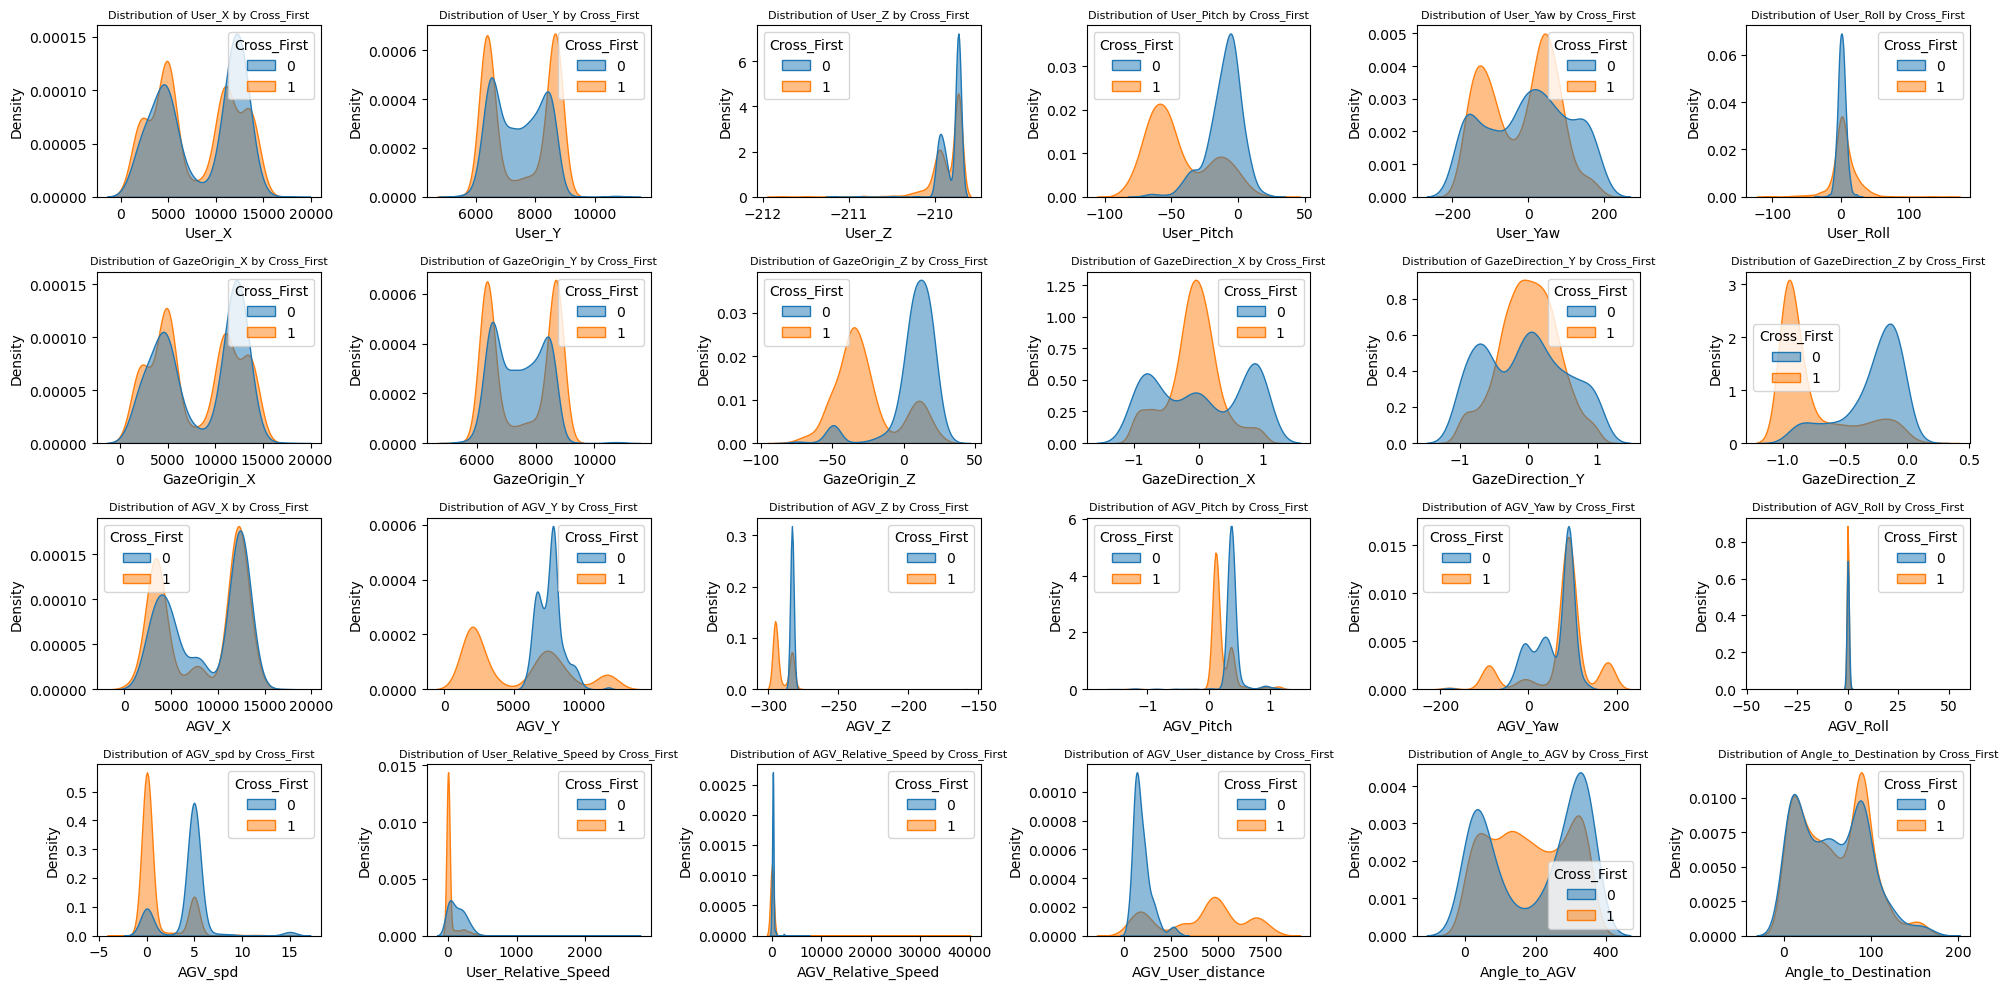

In [33]:
features = ['User_X', 'User_Y', 'User_Z', 'User_Pitch', 'User_Yaw', 'User_Roll',
       'GazeOrigin_X', 'GazeOrigin_Y', 'GazeOrigin_Z',
       'GazeDirection_X', 'GazeDirection_Y', 'GazeDirection_Z','AGV_X', 'AGV_Y', 'AGV_Z', 'AGV_Pitch', 'AGV_Yaw',
       'AGV_Roll', 'AGV_spd', 'User_Relative_Speed', 'AGV_Relative_Speed', 'AGV_User_distance', 'Angle_to_AGV', 'Angle_to_Destination']

plt.figure(figsize=(20, 10))

for i, feature in enumerate(features, 1):
    plt.subplot(4, 6, i)
    sns.kdeplot(data=labeled_data, x=feature, hue='Cross_First', common_norm=False, fill=True, alpha=0.5)
    plt.title(f'Distribution of {feature} by Cross_First', fontsize=8)

plt.tight_layout()
filename = f'Feature_Distributions_by_Cross_First_Decision.png'
# plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)
plt.show()

Top Features for Cluster Separation:
                Feature  KS_Statistic     KS_p-value  Mean_Difference
21    AGV_User_distance      0.729160  3.791245e-246      3114.819533
15            AGV_Pitch      0.707271  1.747880e-229         0.159805
8          GazeOrigin_Z      0.702014  1.009237e-225        33.541735
14                AGV_Z      0.694892  1.146713e-220         7.593130
19  User_Relative_Speed      0.642862  1.111187e-185       109.047724
3            User_Pitch      0.634449  2.150010e-180        33.780623
20   AGV_Relative_Speed      0.632029  9.856426e-179       144.351823
18              AGV_spd      0.629897  2.053616e-177         3.269675
11      GazeDirection_Z      0.621782  1.233062e-172         0.474214
13                AGV_Y      0.509447  8.063891e-113      2328.818440
17             AGV_Roll      0.367670   1.500018e-57         0.129585
7          GazeOrigin_Y      0.360196   3.312493e-55        91.440532
1                User_Y      0.318518   4.785655e-43 

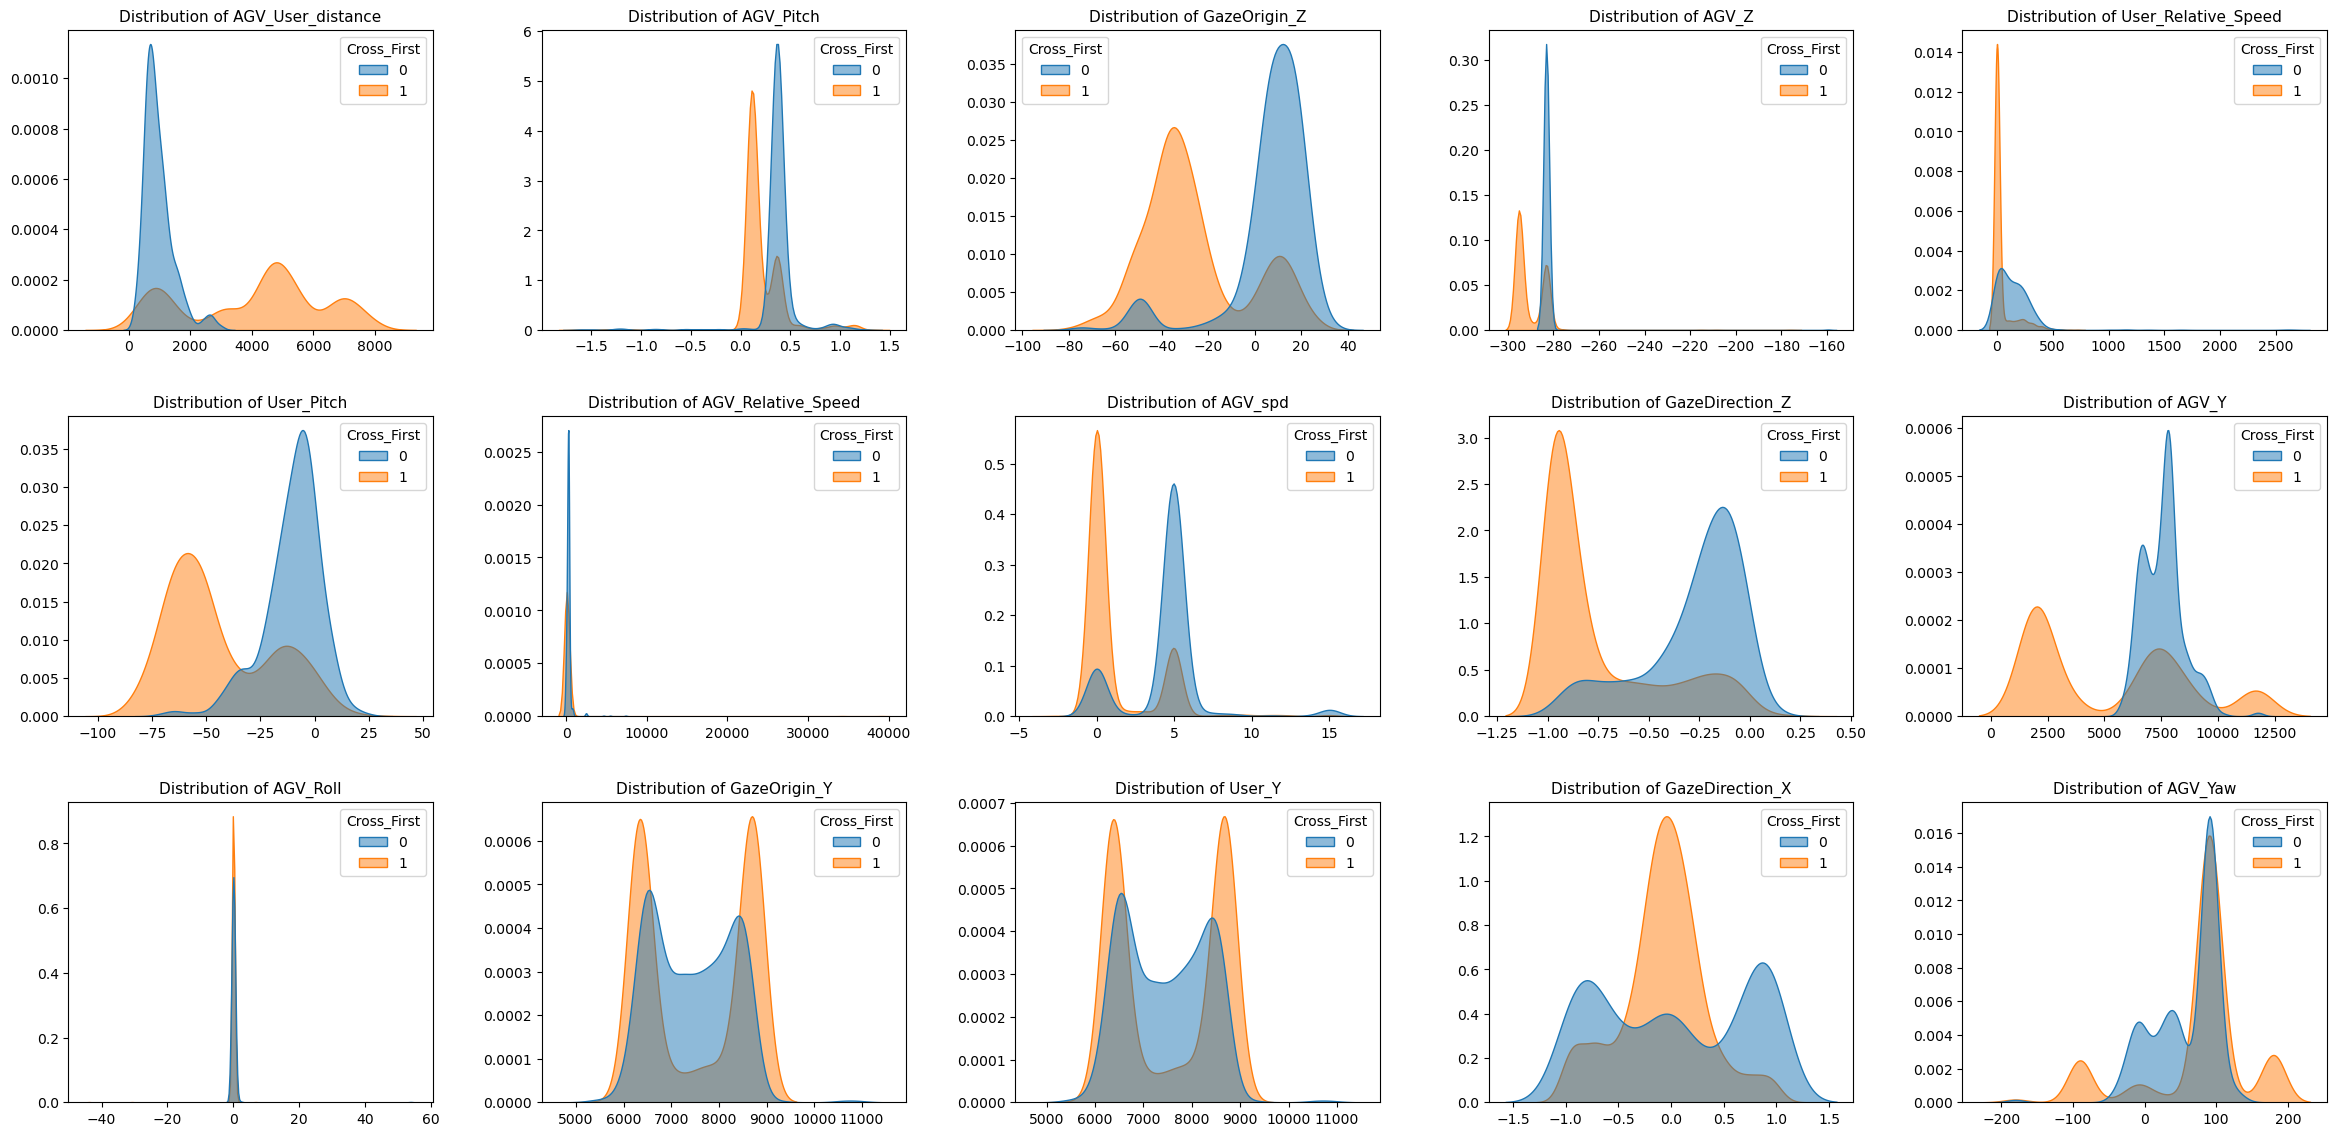

In [127]:
# Define your feature list
features = ['User_X', 'User_Y', 'User_Z', 'User_Pitch', 'User_Yaw', 'User_Roll',
       'GazeOrigin_X', 'GazeOrigin_Y', 'GazeOrigin_Z',
       'GazeDirection_X', 'GazeDirection_Y', 'GazeDirection_Z','AGV_X', 'AGV_Y', 'AGV_Z', 'AGV_Pitch', 'AGV_Yaw',
       'AGV_Roll', 'AGV_spd', 'User_Relative_Speed', 'AGV_Relative_Speed', 'AGV_User_distance', 'Angle_to_AGV', 'Angle_to_Destination']

# Create an empty list to store results
results = []

for feature in features:
    # Get values for each cluster
    cluster_0 = labeled_data[labeled_data['Cross_First'] == 0][feature].dropna()
    cluster_1 = labeled_data[labeled_data['Cross_First'] == 1][feature].dropna()

    # Perform Kolmogorov-Smirnov test
    ks_stat, ks_pval = stats.ks_2samp(cluster_0, cluster_1)

    # Compute mean difference
    mean_diff = abs(cluster_0.mean() - cluster_1.mean())

    # Append results
    results.append([feature, ks_stat, ks_pval, mean_diff])

# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=['Feature', 'KS_Statistic', 'KS_p-value', 'Mean_Difference'])

# Sort by KS statistic (higher values = better separation)
results_df = results_df.sort_values(by='KS_Statistic', ascending=False)

# Display the most distinguishing features
print("Top Features for Cluster Separation:")
print(results_df.head(15))  # Show top 10 best features

# Optional: Visualizing the top 5 distinguishing features
top_features = results_df.head(15)['Feature'].tolist()

plt.figure(figsize=(24, 12))  # increased height

for i, feature in enumerate(top_features, 1):
    plt.subplot(3, 5, i)
    sns.kdeplot(data=labeled_data, x=feature, hue='Cross_First', common_norm=False, fill=True, alpha=0.5)
    plt.title(f'Distribution of {feature}', fontsize=11)
    plt.xlabel('')
    plt.ylabel('')

# Adjust spacing *before* saving
plt.tight_layout(pad=3.0)  # you can tweak `pad` to increase space between plots

# Save after layout is adjusted
filename = f'Feature_Distributions_by_Cross_First_Decision.png'
save_path = os.path.join(save_dir, filename)
plt.savefig(save_path, dpi=300, bbox_inches='tight')

print(f"Plot saved to: {save_path}")
plt.show()

In [35]:
top_features = ['AGV_User_distance', 'AGV_Pitch', 'GazeOrigin_Z', 'AGV_Z', 'User_Relative_Speed', 
                'User_Pitch', 'AGV_Relative_Speed','AGV_spd','GazeDirection_Z', 'AGV_Y',
               'AGV_Roll', 'GazeOrigin_Y', 'User_Y', 'GazeDirection_X', 'AGV_Yaw']

In [36]:
columns_to_keep = ['Cross_First'] + features
labeled_features = labeled_data[columns_to_keep]
unlabeled_features = unlabeled_data[columns_to_keep]

In [37]:
# Create balanced test_mask: 50% "User", 50% "AGV"
user_samples = labeled_data[labeled_data['Cross_First'] == 1].sample(n=50, random_state=42)
agv_samples = labeled_data[labeled_data['Cross_First'] == 0].sample(n=50, random_state=42)
test_mask = pd.concat([user_samples, agv_samples], axis=0).sample(frac=1, random_state=42)

# Keep ground-truth labels and track original index
test_labels = test_mask[['Cross_First']].copy()
test_labels['X_index'] = test_mask.index  # store original index for test data

# Remove labels (simulate unlabeled) and preserve index
test_mask = test_mask.copy()
test_mask['Cross_First'] = None
test_mask['X_index'] = test_mask.index

# Remove from labeled set and preserve index
remaining_labeled_data = labeled_data.drop(test_mask.index).copy()
remaining_labeled_data['X_index'] = remaining_labeled_data.index

# Append test_mask to the unlabeled data and preserve index
unlabeled_data = unlabeled_data.copy()
unlabeled_data['X_index'] = unlabeled_data.index
updated_unlabeled_data = pd.concat([unlabeled_data, test_mask], ignore_index=True)

# Combine all metadata into one DataFrame for tracking
combined_df = pd.concat([remaining_labeled_data, updated_unlabeled_data], ignore_index=True)

# Prepare inputs for the semi-supervised algorithm
X_all = combined_df[top_features].values
y_labeled = remaining_labeled_data['Cross_First'].values
X_index_all = combined_df['X_index'].values  # Save for back-mapping

# Track indices
num_labeled = len(remaining_labeled_data)
num_unlabeled = len(updated_unlabeled_data)
labeled_indices = np.arange(num_labeled)
unlabeled_indices = np.arange(num_labeled, num_labeled + num_unlabeled)

# Save test ground-truth for later comparison
test_ground_truth = test_labels['Cross_First'].values
test_indices = test_labels['X_index'].values  # so we can identify test rows later

In [42]:
# Create balanced test_mask: 50% "User", 50% "AGV"
user_samples.head()

,User_X,User_Y,User_Z,User_Pitch,User_Yaw,User_Roll,U_X,U_Y,U_Z,GazeOrigin_X,...,DRate,User_Relative_Speed,AGV_Relative_Speed,AGV_User_distance,EyeTarget,Angle_to_AGV,AGV_in_FOV,Angle_to_Destination,Destination_in_FOV,Cross_First
10892,8332.066857,8790.729143,-209.725,-9.461208,15.963650,3.583023,-28.645143,-31.650429,232.459857,8365.238600,...,Low,183.370505,247.855665,754.144693,NW_FactoryFloor61,50.807160,True,90.000000,True,1
129637,4924.948000,6366.377000,-210.175,-48.402418,25.476465,5.428907,24.892250,14.948250,168.997000,4900.055750,...,Low,0.000000,0.000000,5443.814174,BP_CheckPoint4,122.561782,False,34.447317,True,1
48947,8629.957143,8584.702571,-209.725,-1.537149,-4.194917,1.425390,-95.373429,58.532429,215.521429,8727.414000,...,High,227.164664,231.775603,944.811838,AGV_Sphere12,15.835248,True,158.496197,False,1
36822,3642.270000,7050.598143,-209.725,-10.001794,-48.618367,4.088598,-2.860429,-22.483857,219.213143,3647.139429,...,High,212.630806,247.687119,822.965863,AGV_Sphere14,25.580399,True,80.818763,True,1
108397,2119.100429,8095.178571,-209.943,-6.350814,-89.103713,3.445895,-8.611286,-19.646857,214.989857,2127.749143,...,Low,42.981612,231.882211,942.724803,SM_Wall_Divider_01_5m4,96.687464,False,5.604930,True,1


In [44]:
scaler = StandardScaler()
X_all = scaler.fit_transform(X_all)

In [86]:
def compute_mst(X, cosine_threshold = 0.7):
    G = nx.Graph()
    n_samples = X.shape[0]

    sim_matrix = cosine_similarity(X)
    for i in range(n_samples):
        for j in range(i + 1, n_samples):
            similarity = sim_matrix[i, j]
            if similarity > cosine_threshold:
                G.add_edge(i, j, weight=1 - similarity)

    mst = nx.minimum_spanning_tree(G)
    return mst

mst_graph = compute_mst(X_all)

In [87]:
def propagate_labels(mst, y_labeled, labeled_indices, num_total_samples):
    propagated_labels = np.full(num_total_samples, -1)
    costs = np.full(num_total_samples, np.inf)
    heap = []

    # Initialize with labeled points
    for idx in labeled_indices:
        propagated_labels[idx] = y_labeled[idx]
        costs[idx] = 0
        heapq.heappush(heap, (0, idx))

    # Label propagation
    while heap:
        cost, current_node = heapq.heappop(heap)
        for neighbor in mst.neighbors(current_node):
            edge_weight = mst[current_node][neighbor]['weight']
            path_cost = max(cost, edge_weight)
            if path_cost < costs[neighbor]:
                costs[neighbor] = path_cost
                propagated_labels[neighbor] = propagated_labels[current_node]
                heapq.heappush(heap, (path_cost, neighbor))

    return propagated_labels

# Run label propagation
propagated_labels = propagate_labels(mst_graph, y_labeled, labeled_indices, X_all.shape[0])

In [88]:
len(propagated_labels)

7481

In [89]:
# Step 1: Determine number of test samples
num_test_samples = len(test_ground_truth)

# Step 2: Extract the propagated labels from the *end* of X_all
test_predicted_labels = propagated_labels[-num_test_samples:]

# Step 3: Evaluate
accuracy = accuracy_score(test_ground_truth, test_predicted_labels)
print(f"Accuracy on test set: {accuracy:.2f}")

# Optional: more detailed metrics
print("\nClassification Report:")
print(classification_report(test_ground_truth, test_predicted_labels))

Accuracy on test set: 0.90

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90        50
           1       0.92      0.88      0.90        50

    accuracy                           0.90       100
   macro avg       0.90      0.90      0.90       100
weighted avg       0.90      0.90      0.90       100



In [90]:
# Build label DataFrame with row identity
label_df = pd.DataFrame({
    'X_index': X_index_all,
    'Predicted_Cross_First': propagated_labels
})

# Mark test samples (optional but useful for eval/merging logic)
label_df['IsTest'] = label_df['X_index'].isin(test_indices)

# Optionally add true labels (for eval only)
true_labels_df = pd.DataFrame({
    'X_index': test_indices,
    'True_Cross_First': test_ground_truth
})
label_df = label_df.merge(true_labels_df, on='X_index', how='left')

In [91]:
label_df

,X_index,Predicted_Cross_First,IsTest,True_Cross_First
0,0,1,False,NaN
1,126,1,False,NaN
2,127,1,False,NaN
3,426,1,False,NaN
4,427,1,False,NaN
...,...,...,...,...
7476,120657,0,True,0.0
7477,26635,0,True,0.0
7478,29502,1,True,1.0
7479,40343,0,True,0.0


In [92]:
# First, set the index of label_df to 'X_index'
label_df_indexed = label_df.set_index('X_index')

# Then, join on the index of interaction_five_sec_prior
interaction_five_sec_prior = interaction_five_sec_prior.join(
    label_df_indexed[['Predicted_Cross_First', 'IsTest', 'True_Cross_First']],
    how='left'
)

In [93]:
interaction_five_sec_prior.iloc[0:50]

,User_X,User_Y,User_Z,User_Pitch,User_Yaw,User_Roll,U_X,U_Y,U_Z,GazeOrigin_X,...,AGV_User_distance,EyeTarget,Angle_to_AGV,AGV_in_FOV,Angle_to_Destination,Destination_in_FOV,Cross_First,Predicted_Cross_First,IsTest,True_Cross_First
0,2200.416000,8600.156000,-209.963,-11.479123,-118.365545,3.151699,45.116500,-89.558000,160.919000,2155.299333,...,1275.129829,BP_Affordance_C_2,213.839254,False,3.404290,True,User,1,False,NaN
121,2383.057000,8100.975429,-209.760,-26.706478,75.624285,3.646379,28.278714,-76.001571,157.008429,2354.617571,...,272.099239,NW_FactoryFloor77,91.670282,False,3.404290,True,None,1,False,NaN
122,2383.057000,8100.975429,-209.760,-26.706478,75.624285,3.646379,28.278714,-76.001571,157.008429,2354.617571,...,272.099239,NW_FactoryFloor77,91.670282,False,3.404290,True,None,1,False,NaN
123,2383.057000,8100.975429,-209.760,-26.706478,75.624285,3.646379,28.278714,-76.001571,157.008429,2354.617571,...,272.099239,NW_FactoryFloor77,91.670282,False,3.404290,True,None,1,False,NaN
124,2383.057000,8100.975429,-209.760,-26.706478,75.624285,3.646379,28.278714,-76.001571,157.008429,2354.617571,...,272.099239,NW_FactoryFloor77,91.670282,False,3.404290,True,None,1,False,NaN
125,2383.057000,8100.975429,-209.760,-26.706478,75.624285,3.646379,28.278714,-76.001571,157.008429,2354.617571,...,272.099239,NW_FactoryFloor77,91.670282,False,3.404290,True,None,1,False,NaN
126,2437.337571,8100.399286,-209.760,-37.532870,-77.069392,6.789677,8.233571,-81.729286,148.192000,2426.778857,...,271.560169,NW_FactoryFloor77,96.876571,False,3.404290,True,User,1,False,NaN
127,4931.329000,6366.571000,-210.021,-16.848541,85.304946,7.902309,52.427250,-30.396250,149.144750,4878.899500,...,5445.066289,BP_Affordance_C_3,175.025233,False,46.170106,True,User,1,False,NaN
421,5391.964000,8136.308000,-209.725,0.646221,-52.607536,5.747819,72.330286,-106.371857,155.996286,5320.782857,...,638.101102,BP_CheckPoint3,281.381273,False,84.451712,True,None,1,False,NaN
422,5391.964000,8136.308000,-209.725,0.646221,-52.607536,5.747819,72.330286,-106.371857,155.996286,5320.782857,...,638.101102,BP_CheckPoint3,281.381273,False,84.451712,True,None,1,False,NaN


C:\Users\HIALAB\AppData\Local\Temp\ipykernel_14764\2673441259.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.iloc[1:])  # drop first entry


Plot saved to ./Images/Crossing_Behavior_Timeline_FOV_Overlay.png


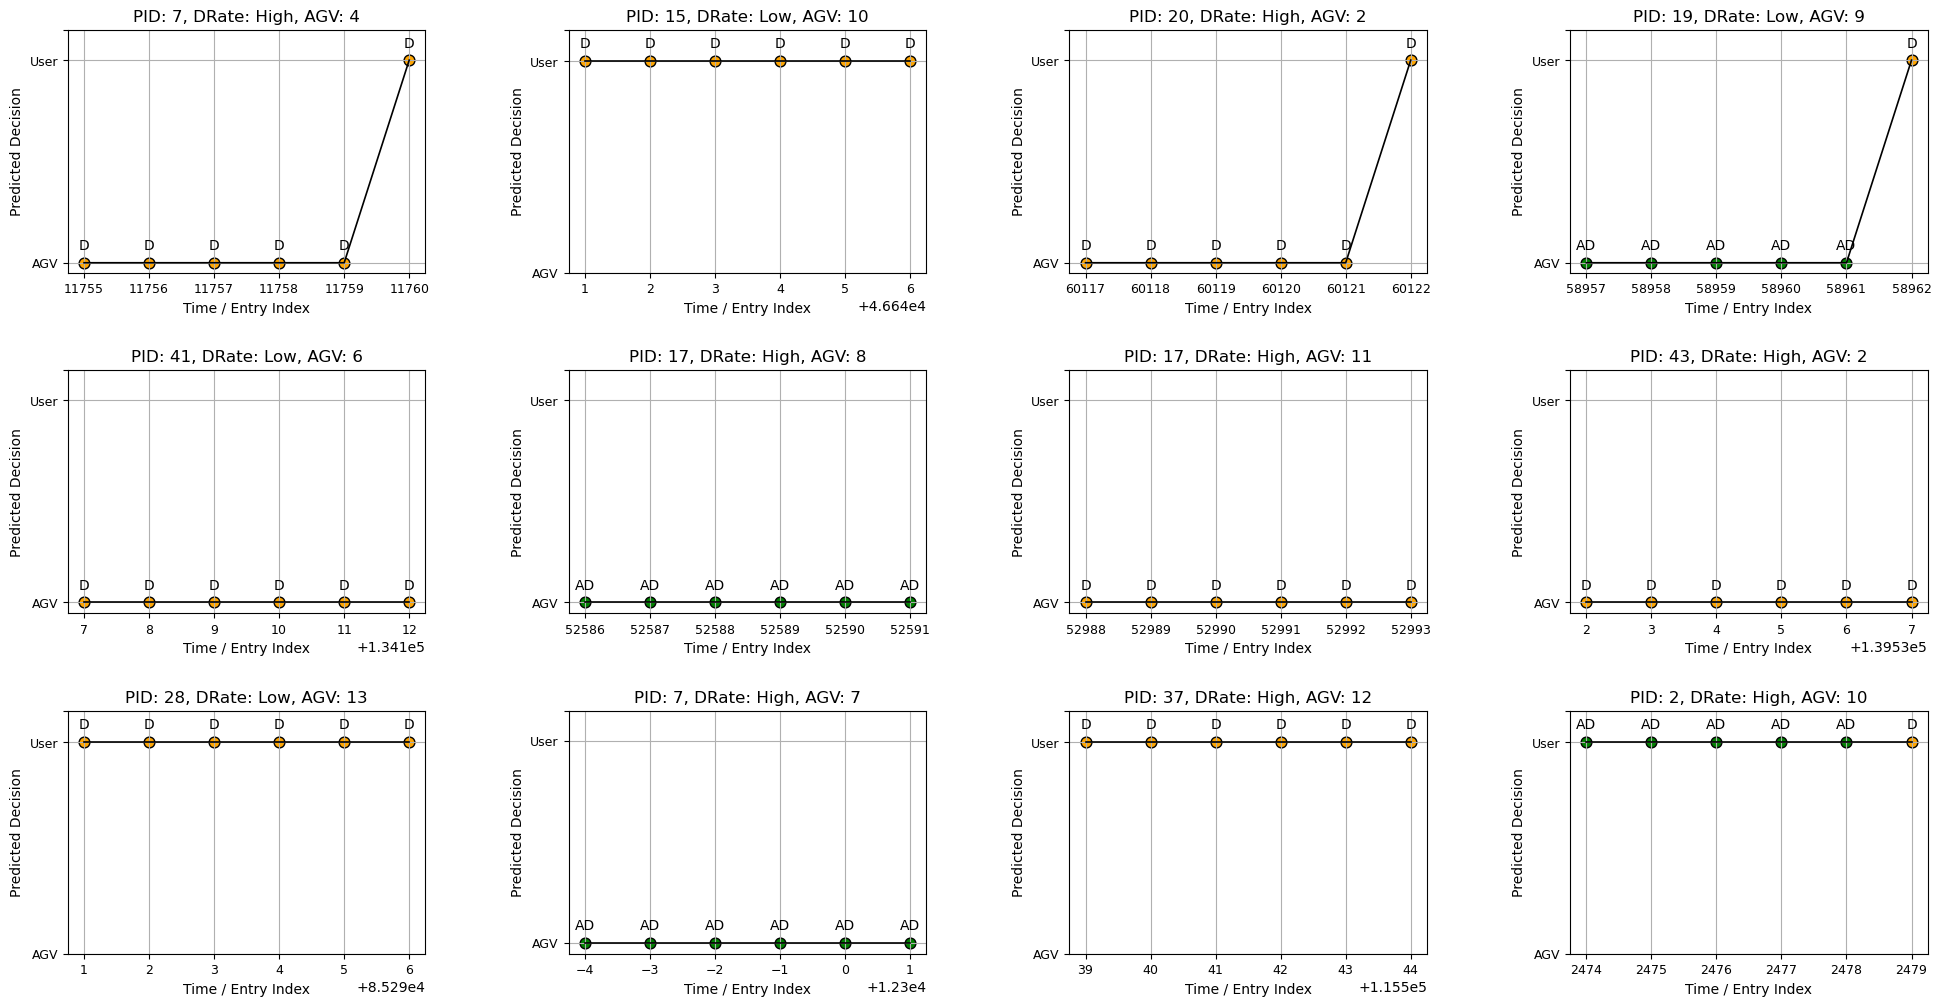

In [129]:
# Step 1: Filter out first entry per group
filtered_df = (
    interaction_five_sec_prior
    .sort_index()
    .groupby(['PID', 'DRate', 'AGVname'], group_keys=False)
    .apply(lambda group: group.iloc[1:])  # drop first entry
    .copy()
)

# Step 2: Add FOV_State column (00, 01, 10, 11)
def encode_fov(row):
    return f"{int(row['AGV_in_FOV'])}{int(row['Destination_in_FOV'])}"

filtered_df['FOV_State'] = filtered_df.apply(encode_fov, axis=1)

# Step 3: Define color palette for marker coloring
fov_palette = {
    '00': 'gray',    # AGV=False, Dest=False
    '01': 'orange',  # AGV=False, Dest=True
    '10': 'blue',    # AGV=True, Dest=False
    '11': 'green'    # AGV=True, Dest=True
}

# Step 4: Randomly select 8 combinations
unique_combinations = filtered_df[['PID', 'DRate', 'AGVname']].drop_duplicates()
random_combinations = unique_combinations.sample(n=12, random_state=25)

# Step 5: Plot setup
fig, axes = plt.subplots(3, 4, figsize=(24, 12))

for ax, (_, row) in zip(axes.flat, random_combinations.iterrows()):
    pid, drate, agvname = row['PID'], row['DRate'], row['AGVname']

    subset_df = filtered_df[
        (filtered_df['PID'] == pid) &
        (filtered_df['DRate'] == drate) &
        (filtered_df['AGVname'] == agvname)
    ]

    # Line plot for predicted values
    sns.lineplot(
        data=subset_df,
        x=subset_df.index,
        y="Predicted_Cross_First",
        ax=ax,
        color="black",
        linewidth=1.2
    )

    # Color-coded markers + label with A/D/AD
    for fov_state, sub in subset_df.groupby('FOV_State'):
        ax.scatter(
            sub.index,
            sub['Predicted_Cross_First'],
            label=fov_state,
            color=fov_palette.get(fov_state, 'black'),
            s=60,
            edgecolor='black'
        )

        # Add text labels (A/D/AD)
        for i, point in sub.iterrows():
            label = ''
            if point['AGV_in_FOV']:
                label += 'A'
            if point['Destination_in_FOV']:
                label += 'D'
            if label:  # Only add label if one or both are True
                ax.text(
                    x=point.name,  # use DataFrame index (matches x-axis)
                    y=point['Predicted_Cross_First'] + 0.05,  # small vertical offset
                    s=label,
                    fontsize=10,
                    ha='center',
                    va='bottom',
                    color='black'
                )

    # Format axes
    ax.set_xlabel("Time / Entry Index", fontsize=10)
    ax.set_ylabel("Predicted Decision", fontsize=10)
    ax.set_yticks([0, 1, 1.15])
    ax.set_yticklabels(['AGV', 'User', ''], fontsize=10)
    ax.set_title(f"PID: {pid}, DRate: {drate}, AGV: {agvname}", fontsize=12)
    ax.tick_params(axis='both', labelsize=9)
    ax.grid(True)
    ax.legend().remove()

# Add shared legend
handles, labels = ax.get_legend_handles_labels()
# fig.legend(handles, labels, title="FOV State (AGV-Dest)", loc='upper right')

plt.subplots_adjust(wspace=0.4, hspace=0.4)

# Save after layout is adjusted
filename = f'Crossing_Behavior_Timeline_FOV_Overlay.png'
save_path = os.path.join(save_dir, filename)
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Plot saved to {save_path}")

plt.show()

### Does the user’s decision to cross first depend on whether they could see the destination?

In [96]:
# Copy and ensure binary columns
analysis_df = interaction_five_sec_prior[['Predicted_Cross_First', 'Destination_in_FOV', 'AGV_in_FOV']].copy()

analysis_df['User_Crosses_First'] = analysis_df['Predicted_Cross_First'] == 1
analysis_df['Destination_Seen'] = analysis_df['Destination_in_FOV'] == True
analysis_df['AGV_Seen'] = analysis_df['AGV_in_FOV'] == True

In [97]:
# Destination in FOV
cont_dest = pd.crosstab(analysis_df['User_Crosses_First'], analysis_df['Destination_Seen'])
chi2_d, p_d, _, _ = chi2_contingency(cont_dest)

print("User Crossing vs. Destination in FOV")
print(cont_dest)
print(f"Chi-square = {chi2_d:.2f}, p = {p_d:.4f}")

User Crossing vs. Destination in FOV
Destination_Seen    False  True 
User_Crosses_First              
False                 548   3600
True                  452   2881
Chi-square = 0.17, p = 0.6831


In [98]:
# AGV in FOV
cont_agv = pd.crosstab(analysis_df['User_Crosses_First'], analysis_df['AGV_Seen'])
chi2_a, p_a, _, _ = chi2_contingency(cont_agv)

print("\n User Crossing vs. AGV in FOV")
print(cont_agv)
print(f"Chi-square = {chi2_a:.2f}, p = {p_a:.4f}")


 User Crossing vs. AGV in FOV
AGV_Seen            False  True 
User_Crosses_First              
False                2698   1450
True                 2482    851
Chi-square = 76.62, p = 0.0000


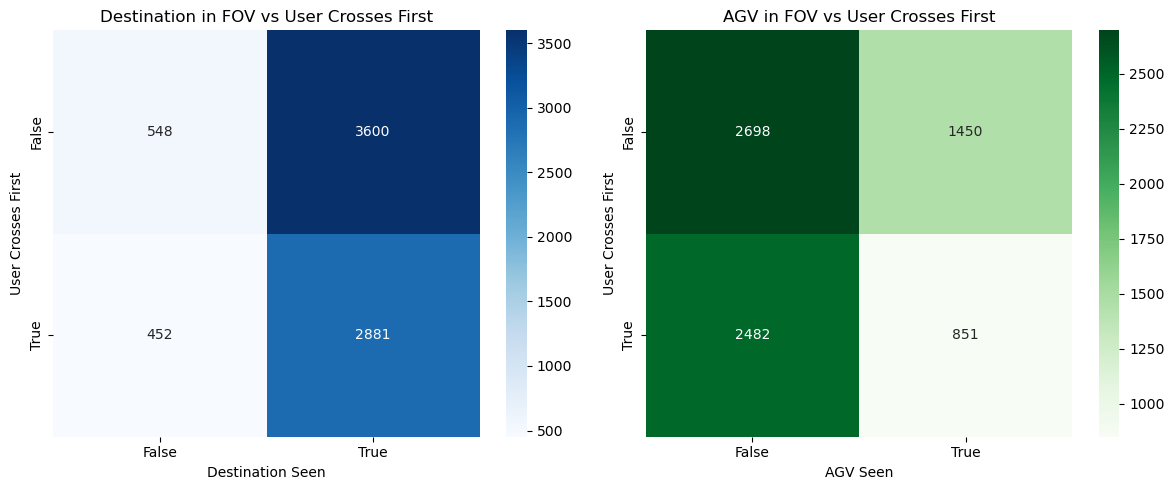

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cont_dest, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Destination in FOV vs User Crosses First")
axes[0].set_xlabel("Destination Seen")
axes[0].set_ylabel("User Crosses First")

sns.heatmap(cont_agv, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("AGV in FOV vs User Crosses First")
axes[1].set_xlabel("AGV Seen")
axes[1].set_ylabel("User Crosses First")

plt.tight_layout()
plt.show()

<Axes: xlabel='Predicted_Cross_First', ylabel='AGV_User_distance'>

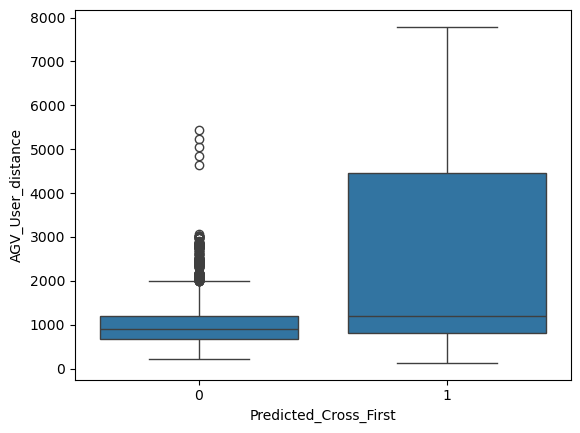

In [100]:
sns.boxplot(
    x='Predicted_Cross_First',
    y='AGV_User_distance',
    data=interaction_five_sec_prior
)